Використай цей шаблон в роботі з датасетом. Ти можеш додавати комірки за потреби, але не змінюй структуру і послідовність питань. Обмежся функціями з наведених бібліотек.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

1. Завантаж датасет з бібліотеки seaborn:

In [2]:
# Завантажуємо датасет Titanic з бібліотеки seaborn:
td = sns.load_dataset("titanic")

2. Переглянь перші рядки датасету. Зроби висновок, чи коректно він завантажився.

In [3]:
# Дивимось перші рядки датасету
print(td.head())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


3. Перевір типи стовпців. Які з них потребують перетворення?

In [4]:
# Перевіряємо типи стовпців. Які з них потребують перетворення?
print(td.dtypes)

survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object


4. Перевір статистику по УСІМ стовпцям датасету.

In [5]:
# Виводимо статистику по УСІМ стовпцям датасету
td.describe(include="all")

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


5. Спробуй оцінити кількість дублікатів. Виміряй число рядків, позбудься дублікатів, оціни нову кількість рядків. Різницю виведи на екран, це і буде кількість рядків.

In [6]:
# Виміряй число рядків
n_rows = len(td)
print(f"Загальна кількість рядків = {n_rows}")

# Позбудься дублікатів
td = td.drop_duplicates()
n_unique = len(td)

# Оціни нову кількість рядків. Різницю виведи на екран, це і буде кількість рядків
print(f"Видалено {n_rows - n_unique} рядків")
print(f"Кількість рядків, що залишилось = {len(td)}")

Загальна кількість рядків = 891
Видалено 107 рядків
Кількість рядків, що залишилось = 784


6. Необхідно створити єдиний стовпчик, що вказує кількість родичів для кожного пасажира на борту, замість:
Кількість братів/сестер або чоловіків/дружин на борту
Кількість батьків або дітей на борту
Булева ознака: True, якщо пасажир подорожував один (без родичів на борту)
після створення нового стовпчика, дропни попередні. Вони вже не потрібні.

In [7]:
# створити єдиний стовпчик, що вказує кількість родичів для кожного пасажира на борту, 
# замість: Кількість братів/сестер або чоловіків/дружин на борту Кількість батьків або дітей на борту
td['relatives'] = td['sibsp'] + td['parch']

# Булева ознака: True, якщо пасажир подорожував один (без родичів на борту)
td['is_alone'] = td['relatives'] == 0

# Видаляємо непотрібні стовпчики sibsp, parch, alone
td = td.drop(['sibsp', 'parch', 'alone'], axis=1).reset_index()

7. Перевір частоту випадків за значеннями в  новому стовпчику (кількість родичів) використовуючи візуалізацію:

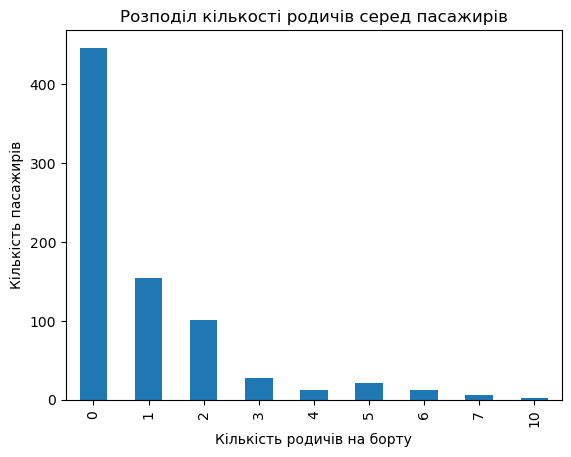

In [8]:
count = td['relatives'].value_counts()

td['relatives'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('Кількість родичів на борту')
plt.ylabel('Кількість пасажирів')
plt.title('Розподіл кількості родичів серед пасажирів')
plt.show()

8. Використовуючи лямбда функцію заміни кількість родичів, що перевищує число 5(п'ять) на значення "above 5"(понад п'ять):

In [9]:
# Перетворюємо колонку "relatives" в числа
td['relatives'] = td['relatives'].astype(int)
# Використовуємо лямбда функцію
td['relatives'] = td['relatives'].apply(lambda x: "above 5" if x > 5 else x)

9. Необхідно вивести на екран статистику по модифікованому стовпцю, віднісши нову категорію в кінець( для цього слід перетворити стовпець в категорійний):

relatives
0          446
1          154
2          101
3           28
4           13
5           22
above 5     20
Name: count, dtype: int64


<Axes: xlabel='relatives'>

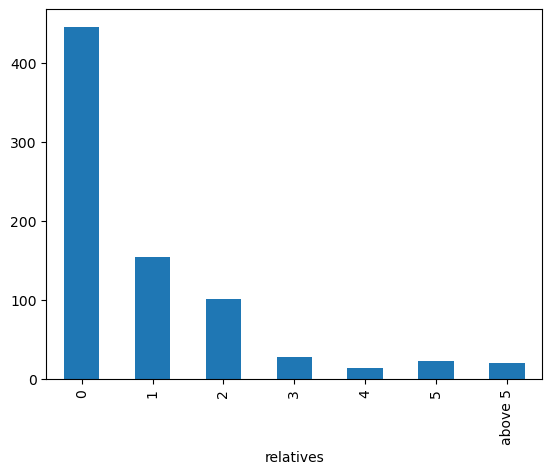

In [10]:
# Робимо категорії та задаємо порядок категорій
td['relatives'] = pd.Categorical(
    td['relatives'],
    categories=[0, 1, 2, 3, 4, 5, 'above 5'], ordered = True
)
# Виводимо статистику
print(td['relatives'].value_counts().sort_index())
# Робимо візуалізацію
td['relatives'].value_counts().sort_index().plot(kind='bar')

10. Заповни відсутні значення віку медіаною.

In [11]:
# Знаходимо рядок в якому відсутнє значення віку (267)
print(td.loc[265:272], '\n\n')

# Замінюємо відсутні значення на медіану і зберігаємо результат в новий стовпчик
td['med_age'] = td['age'].fillna(td['age'].median())

# Перевіряємо результат на рядку 267 (медіанний вік 28.25)
print('Result\n\n', td.loc[265:272])

     index  survived  pclass     sex   age     fare embarked   class    who  \
265    282         0       3    male  16.0   9.5000        S   Third    man   
266    283         1       3    male  19.0   8.0500        S   Third    man   
267    284         0       1    male   NaN  26.0000        S   First    man   
268    285         0       3    male  33.0   8.6625        C   Third    man   
269    286         1       3    male  30.0   9.5000        S   Third    man   
270    287         0       3    male  22.0   7.8958        S   Third    man   
271    288         1       2    male  42.0  13.0000        S  Second    man   
272    289         1       3  female  22.0   7.7500        Q   Third  woman   

     adult_male deck  embark_town alive relatives  is_alone  
265        True  NaN  Southampton    no         0      True  
266        True  NaN  Southampton   yes         0      True  
267        True    A  Southampton    no         0      True  
268        True  NaN    Cherbourg    no 

11. Створи новий стовпець, де вік представлено категорією, замість числа (наприклад: до 14 років, 14-34 роки, 35-59 років, 60 і більше років). Виконай задачу з використанням користувацької функції. Осіб з невідомим віком познач відповідно.

In [12]:
# Пишемо користувацьку функцію для групування віку
def convert_age_cat(age_val):
    if age_val < 14: return 'до 14 років'
    elif 14 <= age_val <= 34: return '14-34 роки'
    elif 34 <= age_val <= 59: return '35-59 років'
    elif age_val > 59: return '60 і більше років'
    else: return 'невідомо'
        
# Викликаємо функцію і зберігаємо результат в новий стовпчик
td['age_cat'] = td['med_age'].apply(convert_age_cat)

# Перевіряємо результат
td.loc[265:272]

,index,survived,pclass,sex,age,fare,embarked,class,who,adult_male,deck,embark_town,alive,relatives,is_alone,med_age,age_cat
265,282,0,3,male,16.0,9.5000,S,Third,man,True,NaN,Southampton,no,0,True,16.00,14-34 роки
266,283,1,3,male,19.0,8.0500,S,Third,man,True,NaN,Southampton,yes,0,True,19.00,14-34 роки
267,284,0,1,male,NaN,26.0000,S,First,man,True,A,Southampton,no,0,True,28.25,14-34 роки
268,285,0,3,male,33.0,8.6625,C,Third,man,True,NaN,Cherbourg,no,0,True,33.00,14-34 роки
269,286,1,3,male,30.0,9.5000,S,Third,man,True,NaN,Southampton,yes,0,True,30.00,14-34 роки
270,287,0,3,male,22.0,7.8958,S,Third,man,True,NaN,Southampton,no,0,True,22.00,14-34 роки
271,288,1,2,male,42.0,13.0000,S,Second,man,True,NaN,Southampton,yes,0,True,42.00,35-59 років
272,289,1,3,female,22.0,7.7500,Q,Third,woman,False,NaN,Queenstown,yes,0,True,22.00,14-34 роки


12. Перевір, в якій віковій категорії була найвища смертність. Для цього рекомендується перетворити стовпець 'alive' в булевий тип. Потім підрахувати загальну кількість пасажирів та кількість тих, хто не вижив. Потім обчисли відносний показниках для кожної категорії.

In [13]:
# Перетворюємо стовпець Alive в булевий тип (yes -> True, else -> False)
td['alive'] = td['alive'].apply(lambda x: True if x == 'yes' else False)

In [14]:
# Підрахувати загальну кількість пасажирів та кількість тих, хто не вижив
age_summary = td.groupby('age_cat')['alive'].agg(
    total = 'count', 
    alive = 'sum'
)
age_summary['died'] = age_summary['total'] - age_summary['alive']

In [15]:
# Обчислюємо відносний показник для кожної категорії
age_summary['survival_rate'] = age_summary['alive'] / age_summary['total']
age_summary['died_rate'] = age_summary['died'] / age_summary['total']
age_summary = age_summary.reindex(['до 14 років', '14-34 роки', '35-59 років', '60 і більше років', 'невідомо'])

print(age_summary)

                   total  alive   died  survival_rate  died_rate
age_cat                                                         
до 14 років         70.0   41.0   29.0       0.585714   0.414286
14-34 роки         482.0  189.0  293.0       0.392116   0.607884
35-59 років        206.0   86.0  120.0       0.417476   0.582524
60 і більше років   26.0    7.0   19.0       0.269231   0.730769
невідомо             NaN    NaN    NaN            NaN        NaN


In [16]:
print(td[td['age_cat'] == 'невідомо'])

Empty DataFrame
Columns: [index, survived, pclass, sex, age, fare, embarked, class, who, adult_male, deck, embark_town, alive, relatives, is_alone, med_age, age_cat]
Index: []


13. Відтвори cтатистику  смертності у вигляді кругової діаграми з розбивкою по віковим групам. Ти помітив, що відсотки відрізняються? Поясни чому.

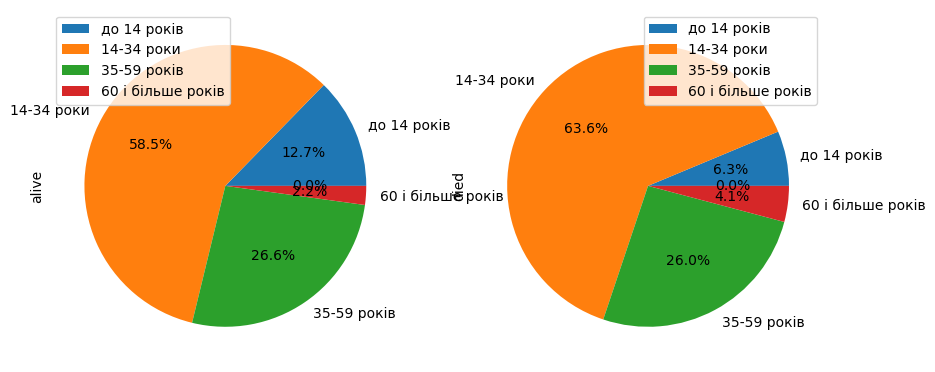

In [17]:
age_summary[['alive','died']].plot(
    kind='pie',
    subplots=True,
    autopct='%1.1f%%',
    figsize=(10,5)
)
plt.show()

In [19]:
# Різниця у відсотках виникає через те, що ми рахували survival_rate відносно кожної категорії, 
#       а в діаграмі отримали survival_rate відносно загальної кількості всіх виживших/померлих

14. *Бонусне завдання*

Підготуй розгорнуту статистику смертності по категорії віку, класу квитка, рівню каюти та кількості родичів. Які фактори, на твою думку, найбільше пов'язані з рівнем смерності? (наприклад: найбільша смертність у відсотковому значенні спостерігається серед вікової групи ... класу квитка.... при наявності ... родичів та для рівня каюти.... Фактор ... має найвищий вплив на смертність)

                   total  alive  died  survival_rate  died_rate
age_cat                                                        
14-34 роки           482    189   293       0.392116   0.607884
35-59 років          206     86   120       0.417476   0.582524
60 і більше років     26      7    19       0.269231   0.730769
до 14 років           70     41    29       0.585714   0.414286


        total  alive  died  survival_rate  died_rate
class                                               
First     214    135    79       0.630841   0.369159
Second    165     84    81       0.509091   0.490909
Third     405    104   301       0.256790   0.743210


      total  alive  died  survival_rate  died_rate
deck                                              
A        15      7     8       0.466667   0.533333
B        46     34    12       0.739130   0.260870
C        59     35    24       0.593220   0.406780
D        33     25     8       0.757576   0.242424
E        32     24     8       0.750000  

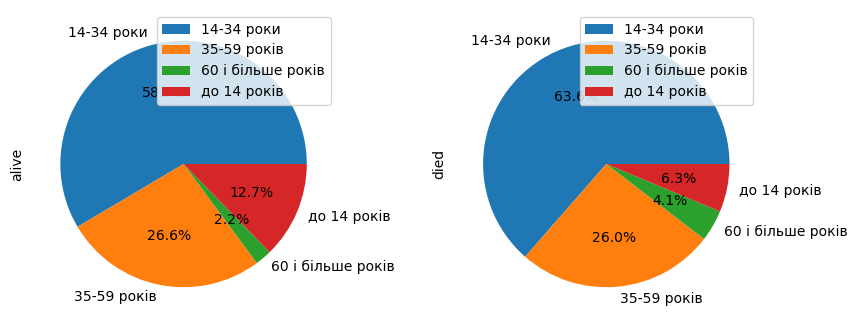

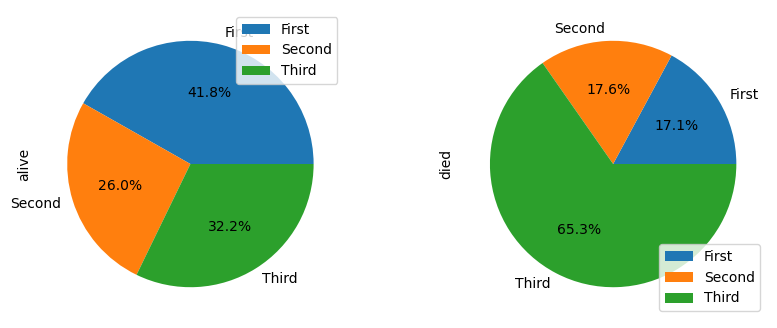

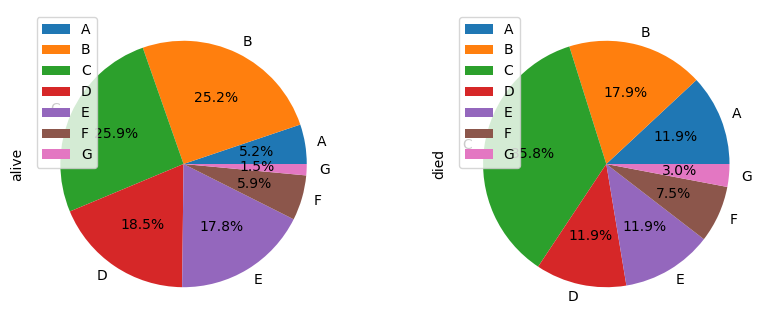

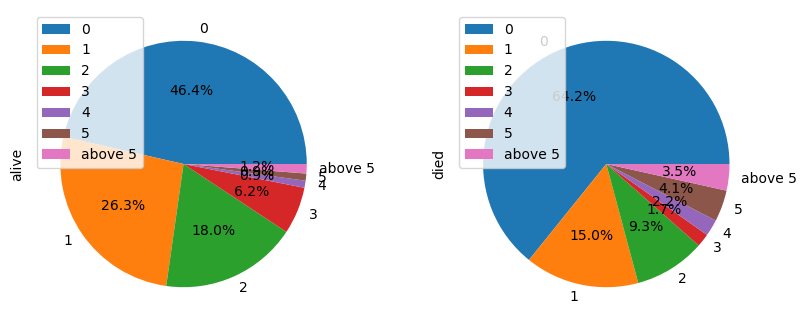

In [18]:
# Робиму користувацьку функцію для підрахування статистики смертності по категоріях
def grouping(cols, alive_col='alive'):
    summary = td.groupby(cols, observed=True).agg(
        total=(alive_col, 'count'),
        alive=(alive_col, 'sum')
    )
    summary['died'] = summary['total'] - summary['alive']
    summary['survival_rate'] = summary['alive'] / summary['total']
    summary['died_rate'] = summary['died'] / summary['total']
    return summary

# Використовуючи формулу підраховуємо потрібні нам категорії
age_summary = grouping(['age_cat'])
class_summary = grouping(['class'])
deck_summary = grouping(['deck'])
relatives_summary = grouping(['relatives'])

# Виводимо дані згруповані по категоріям
print(age_summary)
print('\n')
print(class_summary)
print('\n')
print(deck_summary)
print('\n')
print(relatives_summary)
print('\n')

# Виводимо діаграми для порівняння із загальними показниками
age_summary[['alive','died']].plot(
    kind='pie',
    subplots=True,
    autopct='%1.1f%%',
    figsize=(10,4)
)
plt.show()

class_summary[['alive','died']].plot(
    kind='pie',
    subplots=True,
    autopct='%1.1f%%',
    figsize=(10,4)
)
plt.show()

deck_summary[['alive','died']].plot(
    kind='pie',
    subplots=True,
    autopct='%1.1f%%',
    figsize=(10,4)
)
plt.show()

relatives_summary[['alive','died']].plot(
    kind='pie',
    subplots=True,
    autopct='%1.1f%%',
    figsize=(10,4)
)
plt.show()

In [ ]:
""" 
Висновки: Які фактори, на твою думку, найбільше пов'язані з рівнем смерності? 

Найбільша смертність у відсотковому значенні спостерігається серед вікової групи: 60+ років в порівнянні по категоріях, 
    та в віці 14-34 в порівнянні по загальній кількості загиблих
Найбільший фактор смертності серед класу квитка: Третій клас в порівнянні по категоріях та в порівнянні по загальній кількості загиблих
Найбільший фактор смертності при наявності родичів: 5 і більше та серед тих, хто мандрував один в порівнянні по загальній кількості загиблих
Найбільший фактор смертності серед рівня каюти: на палубі А та G в порівнянні по категоріях та С в порівнянні по загальній кількості загиблих
"""